In [6]:
import pandas as pd

# Lettura dei file
MEF = pd.read_excel(
    "./Materiale/Redditi_e_principali_variabili_IRPEF_su_base_comunale_CSV_2021.xlsx"
)

ISTAT = pd.read_csv(
    "./Materiale/POSAS_2022_it_Comuni.csv",
    sep=";", encoding='utf-8-sig'
)

# Numero di righe
print("Righe MEF:", len(MEF))
# Righe MEF: 7905

print("Righe ISTAT (grezzo, età singola):", len(ISTAT))
# Righe ISTAT (grezzo, età singola): 806208

# Sezione 2 — Pulizia colonne MEF (rimozione variabili non necessarie)

patterns_to_remove = [
    "Anno di imposta",
    "Reddito da fabbricati",
    "Reddito da partecipazione",
    "Reddito di spettanza dell'imprenditore",
    "Reddito imponibile",
    "Imposta netta",
    "Trattamento spettante",
    "Reddito imponibile addizionale",
    "Addizionale regionale",
    "Addizionale comunale",
]

# Mantiene solo le colonne che NON contengono le stringhe sopra
MEF_clean = MEF.loc[
    :,
    ~MEF.columns.str.contains("|".join(patterns_to_remove), regex=True)
]

print("Colonne MEF dopo la pulizia:", MEF_clean.shape[1])
# Colonne MEF dopo la pulizia: 29

Righe MEF: 7905
Righe ISTAT (grezzo, età singola): 806208
Colonne MEF dopo la pulizia: 29


In [7]:
# Sezione 1 — Costruzione fasce d'età

# Comune in maiuscolo
ISTAT["Comune"] = ISTAT["Comune"].str.upper()

# Creazione fascia_eta
ISTAT["fascia_eta"] = pd.NA

ISTAT.loc[ISTAT["Età"].between(0, 14), "fascia_eta"] = "eta_0_14"
ISTAT.loc[ISTAT["Età"].between(15, 24), "fascia_eta"] = "eta_15_24"
ISTAT.loc[ISTAT["Età"].between(25, 44), "fascia_eta"] = "eta_25_44"
ISTAT.loc[ISTAT["Età"].between(45, 64), "fascia_eta"] = "eta_45_64"

# Esclude Età = 999
ISTAT.loc[
    (ISTAT["Età"] >= 65) & (ISTAT["Età"] < 999),
    "fascia_eta"
] = "eta_65_plus"


# Raggruppamento (mantiene il comune None)
ISTAT = (
    ISTAT
    .groupby(
        ["Codice.comune", "Comune", "fascia_eta"],
        as_index=False,
        dropna=False
    )
    .agg(
        Maschi=("Totale.maschi", "sum"),
        Femmine=("Totale.femmine", "sum"),
        Totale=("Totale", "sum")
    )
)


# Pivot equivalente a pivot_wider()
ISTAT_wide = (
    ISTAT
    .pivot(
        index=["Codice.comune", "Comune"],
        columns="fascia_eta",
        values=["Maschi", "Femmine", "Totale"]
    )
    .fillna(0)
)


# Colonne piatte
ISTAT_wide.columns = [
    f"{var}_{fascia}" for var, fascia in ISTAT_wide.columns
]

ISTAT_wide = ISTAT_wide.reset_index()


print("Comuni unici dopo il pivot:", ISTAT_wide["Codice.comune"].nunique())

Comuni unici dopo il pivot: 7904


In [8]:
# Sezione 1 — Merge ISTAT + MEF, stima autonomi mancanti

# Rinomina colonna codice comune in MEF
MEF_clean = MEF_clean.rename(
    columns={"Codice Istat Comune": "Codice.comune"}
)

# Merge ISTAT + MEF (equivalente a inner_join)
merged_data = ISTAT_wide.merge(
    MEF_clean,
    on="Codice.comune",
    how="inner"
)

print("Comuni dopo il merge ISTAT+MEF:", merged_data.shape[0])
# Atteso: 7904


# Stima autonomi mancanti (celle oscurate MEF sotto soglia privacy)

# coalesce() di R = fillna() in pandas
merged_data["Autonomi_stimati"] = (
    merged_data["Numero contribuenti"]
    - merged_data["Reddito da pensione - Frequenza"].fillna(0)
    - merged_data["Reddito da lavoro dipendente e assimilati - Frequenza"].fillna(0)
)

# if_else() di R = np.where() in pandas
merged_data["Autonomi_privacy_flag"] = (
    (merged_data["Autonomi_stimati"] > 0) &
    (merged_data["Autonomi_stimati"] < 4)
)


# Recupero dei valori oscurati sotto soglia privacy
col_autonomi = "Reddito da lavoro autonomo (comprensivo dei valori nulli) - Frequenza"

merged_data["Reddito da lavoro autonomo (stimato) - Frequenza"] = (
    merged_data[col_autonomi]
    .where(
        ~(
            merged_data[col_autonomi].isna() &
            merged_data["Autonomi_privacy_flag"]
        ),
        merged_data["Autonomi_stimati"]
    )
)


print(
    "Comuni con Autonomi_privacy_flag = TRUE (recuperati dalla stima):",
    merged_data["Autonomi_privacy_flag"].sum()
)
# Atteso: 16

Comuni dopo il merge ISTAT+MEF: 7904
Comuni con Autonomi_privacy_flag = TRUE (recuperati dalla stima): 16


In [9]:
# Verifica del fix Agliè (controllo diretto, come richiesto da Fabio)

agliè_check = (
    merged_data
    .loc[merged_data["Comune"] == "AGLIÈ",
         ["Comune", "Totale_eta_65_plus"]]
)

print(agliè_check)

print("Atteso: circa 700-800 (NON più ~3.249 come nel bug originale)")

  Comune  Totale_eta_65_plus
0  AGLIÈ                 687
Atteso: circa 700-800 (NON più ~3.249 come nel bug originale)


In [12]:
# Patch 1 — Merge dell’istruzione (dato censuario BIS, condizionato età/genere)

# Lettura del file con le quote di istruzione BIS
quota_istruzione = pd.read_csv(
    "./Materiale/quota_istruzione_comuni_finale_BIS.csv"
)

#patch 
quota_istruzione = quota_istruzione.rename(columns={'Codice.comune': 'Codice.comune'})


# Selezione delle colonne necessarie e left join
merged_data = merged_data.merge(
    quota_istruzione[
        [
            "Codice.comune",
            "quota_istruzione_0_Base",
            "quota_istruzione_1_Medio",
            "quota_istruzione_2_Alto"
        ]
    ],
    on="Codice.comune",
    how="left"
)

# Numero di comuni senza corrispondenza
n_mancanti = merged_data["quota_istruzione_0_Base"].isna().sum()

print(
    "Comuni senza corrispondenza istruzione:",
    n_mancanti,
    "su",
    len(merged_data)
)

# Atteso:
# Comuni senza corrispondenza istruzione: 0 su 7904

Comuni senza corrispondenza istruzione: 0 su 7904


In [13]:
# Sezione 2 — M_i, Indice a media semplice (funzione + costruzione)

import numpy as np
import pandas as pd


# Funzione equivalente a minmax_norm() di R
def minmax_norm(x):
    rng = [np.nanmin(x), np.nanmax(x)]
    
    if rng[1] - rng[0] == 0:
        return np.full(len(x), np.nan)
    
    return (x - rng[0]) / (rng[1] - rng[0])


# --- ESEMPIO CONCRETO: comportamento della funzione ---

esempio_x = np.array([10, 50, 100, 500, 1000])

print("Valori di input:", esempio_x)

print(
    "Range (min, max):",
    np.nanmin(esempio_x),
    np.nanmax(esempio_x)
)

print(
    "Output normalizzato (0-1):",
    np.round(minmax_norm(esempio_x), 3)
)

print(
    "Interpretazione: il valore più basso diventa 0, "
    "il più alto diventa 1,"
)

print(
    "gli altri si posizionano proporzionalmente in mezzo."
)


# --- Costruzione M_i ---

merged_data_norm = merged_data.copy()


# Trasformazioni logaritmiche
merged_data_norm["n_contrib_log"] = np.log1p(
    merged_data_norm["Numero contribuenti"]
)

merged_data_norm["dip_log"] = np.log1p(
    merged_data_norm["Reddito da lavoro dipendente e assimilati - Frequenza"]
)

merged_data_norm["pens_log"] = np.log1p(
    merged_data_norm["Reddito da pensione - Frequenza"]
)

merged_data_norm["auto_log"] = np.log1p(
    merged_data_norm["Reddito da lavoro autonomo (stimato) - Frequenza"]
)


# Normalizzazione min-max
merged_data_norm["n_contrib_norm"] = minmax_norm(
    merged_data_norm["n_contrib_log"]
)

merged_data_norm["dip_norm"] = minmax_norm(
    merged_data_norm["dip_log"]
)

merged_data_norm["pens_norm"] = minmax_norm(
    merged_data_norm["pens_log"]
)

merged_data_norm["auto_norm"] = minmax_norm(
    merged_data_norm["auto_log"]
)


# Variabili istruzione
merged_data_norm["edu_base_norm"] = (
    merged_data_norm["quota_istruzione_0_Base"]
)

merged_data_norm["edu_alto_norm"] = (
    merged_data_norm["quota_istruzione_2_Alto"]
)


# Inversione indicatori
merged_data_norm["n_contrib_inv"] = (
    1 - merged_data_norm["n_contrib_norm"]
)

merged_data_norm["dip_inv"] = (
    1 - merged_data_norm["dip_norm"]
)

merged_data_norm["pens_inv"] = (
    1 - merged_data_norm["pens_norm"]
)

merged_data_norm["auto_inv"] = (
    1 - merged_data_norm["auto_norm"]
)


# Coerenza con Shapley:
# - istruzione base aumenta il rischio → non invertita
# - istruzione alta riduce il rischio → invertita

merged_data_norm["edu_base_inv"] = (
    merged_data_norm["edu_base_norm"]
)

merged_data_norm["edu_alto_inv"] = (
    1 - merged_data_norm["edu_alto_norm"]
)


# Numero componenti valide
componenti = [
    "n_contrib_inv",
    "dip_inv",
    "pens_inv",
    "auto_inv",
    "edu_base_inv",
    "edu_alto_inv"
]

merged_data_norm["n_comps_valid"] = (
    merged_data_norm[componenti]
    .notna()
    .sum(axis=1)
)


# Media semplice delle componenti valide
merged_data_norm["indice_privacy_simple"] = (
    merged_data_norm[componenti]
    .mean(axis=1, skipna=True)
)


# Normalizzazione finale 0-1 dell'indice
rng_idx = [
    merged_data_norm["indice_privacy_simple"].min(),
    merged_data_norm["indice_privacy_simple"].max()
]

merged_data_norm["indice_privacy_simple_norm01"] = (
    (merged_data_norm["indice_privacy_simple"] - rng_idx[0])
    /
    (rng_idx[1] - rng_idx[0])
)


# Flag informativi
merged_data_norm["low_info_flag"] = (
    merged_data_norm["n_comps_valid"] < 5
)

merged_data_norm["small_comune_flag"] = (
    merged_data_norm["Numero contribuenti"] < 100
)


print(
    "M_i calcolato per",
    len(merged_data_norm),
    "comuni"
)


# --- TRACCIA: comuni esempio ---

comuni_esempio = [
    "INGRIA",
    "AGLIÈ",
    "ROMA"
]

print(
    "\n=== Traccia dettagliata M_i per Ingria (piccolo), "
    "Agliè (medio), Roma (grande) ==="
)

traccia = (
    merged_data_norm
    .loc[
        merged_data_norm["Comune"].isin(comuni_esempio),
        [
            "Comune",
            "Numero contribuenti",
            "n_contrib_log",
            "n_contrib_norm",
            "n_contrib_inv",
            "edu_base_inv",
            "edu_alto_inv",
            "n_comps_valid",
            "indice_privacy_simple"
        ]
    ]
)

display(traccia)

Valori di input: [  10   50  100  500 1000]
Range (min, max): 10 1000
Output normalizzato (0-1): [0.    0.04  0.091 0.495 1.   ]
Interpretazione: il valore più basso diventa 0, il più alto diventa 1,
gli altri si posizionano proporzionalmente in mezzo.
M_i calcolato per 7904 comuni

=== Traccia dettagliata M_i per Ingria (piccolo), Agliè (medio), Roma (grande) ===


,Comune,Numero contribuenti,n_contrib_log,n_contrib_norm,n_contrib_inv,edu_base_inv,edu_alto_inv,n_comps_valid,indice_privacy_simple
0,AGLIÈ,1963,7.582738,0.381492,0.618508,0.140092,0.860927,6,0.585880
119,INGRIA,31,3.465736,0.011985,0.988015,0.193548,0.967742,6,0.834620
4727,ROMA,1932030,14.474082,1.000000,0.000000,0.089954,0.727612,6,0.136261


In [ ]:
## # A tibble: 3 × 9
##   Comune `Numero contribuenti` n_contrib_log n_contrib_norm n_contrib_inv
##   <chr>                  <dbl>         <dbl>          <dbl>         <dbl>
## 1 AGLIÈ                   1963          7.58         0.381          0.619
## 2 INGRIA                    31          3.47         0.0120         0.988
## 3 ROMA                 1932030         14.5          1              0    
## # ℹ 4 more variables: edu_base_inv <dbl>, edu_alto_inv <dbl>,
## #   n_comps_valid <dbl>, indice_privacy_simple <dbl>

In [14]:
# Controllo M_i — Top 20 e Briga Alta

# Top 20 comuni con indice_privacy_simple più alto
top20 = (
    merged_data_norm
    .sort_values(
        by="indice_privacy_simple",
        ascending=False
    )
    [
        [
            "Codice.comune",
            "Comune",
            "Numero contribuenti",
            "n_comps_valid",
            "indice_privacy_simple"
        ]
    ]
    .head(20)
)

display(top20)

briga_alta = (
    merged_data_norm
    .loc[
        merged_data_norm["Comune"] == "BRIGA ALTA",
        [
            "Comune",
            "Numero contribuenti",
            "n_comps_valid",
            "indice_privacy_simple"
        ]
    ]
)

display(briga_alta)

,Codice.comune,Comune,Numero contribuenti,n_comps_valid,indice_privacy_simple
207,1212,RIBORDONE,45,6,0.868895
581,4103,ISASCA,57,6,0.868538
707,4229,TORRESINA,40,6,0.857653
1611,13233,VAL REZZO,78,6,0.857012
5641,69009,MONTEBELLO SUL SANGRO,58,6,0.853820
229,1234,SALZA DI PINEROLO,48,6,0.853190
1291,10050,RONDANINA,53,6,0.850553
1263,10022,FASCIA,66,6,0.839863
7416,97055,MORTERONE,27,6,0.839506
806,5081,OLMO GENTILE,59,6,0.837993


,Comune,Numero contribuenti,n_comps_valid,indice_privacy_simple
511,BRIGA ALTA,33,5,0.770148


In [15]:
#RIFATTA NUOVA
import numpy as np
import pandas as pd

# Sezione 2 — M_i, Indice a media semplice (funzione + costruzione)

def minmax_norm(x):
    rng = [np.nanmin(x), np.nanmax(x)]
    if rng[1] - rng[0] == 0: 
        return np.full(len(x), np.nan)
    return (x - rng[0]) / (rng[1] - rng[0])

# --- ESEMPIO CONCRETO: come si comporta la funzione, passo per passo ---
esempio_x = np.array([10, 50, 100, 500, 1000], dtype=float)
print("Valori di input:", " ".join(map(str, esempio_x.astype(int))), "\n")

## Valori di input: 10 50 100 500 1000

print("Range (min, max):", int(np.nanmin(esempio_x)), int(np.nanmax(esempio_x)), "\n")

## Range (min, max): 10 1000

# Formatta i decimali eliminando lo zero iniziale per i decimali (stile R: .04, .091)
def r_round(val):
    return f"{val:.3f}".replace("0.", ".").replace("1..", "1.") if val != 0 else "0"

out_norm = [r_round(v) for v in np.round(minmax_norm(esempio_x), 3)]
print("Output normalizzato (0-1):", " ".join(out_norm), "\n")

## Output normalizzato (0-1): 0 .04 .091 .495 1.0

print("Interpretazione: il valore più basso diventa 0, il più alto diventa 1,\n")

## Interpretazione: il valore più basso diventa 0, il più alto diventa 1,

print("gli altri si posizionano proporzionalmente in mezzo.\n")

## gli altri si posizionano proporzionalmente in mezzo.


# --- CONVERSIONE DATAFRAME ---
# Nota: assicuratevi che 'merged_data' sia un DataFrame pandas valido

merged_data_norm = (
    merged_data.copy()
    .assign(
        n_contrib_log=lambda d: np.log1p(d['Numero contribuenti']),
        dip_log=lambda d: np.log1p(d['Reddito da lavoro dipendente e assimilati - Frequenza']),
        pens_log=lambda d: np.log1p(d['Reddito da pensione - Frequenza']),
        auto_log=lambda d: np.log1p(d['Reddito da lavoro autonomo (stimato) - Frequenza'])
    )
    .assign(
        n_contrib_norm=lambda d: minmax_norm(d['n_contrib_log']),
        dip_norm=lambda d: minmax_norm(d['dip_log']),
        pens_norm=lambda d: minmax_norm(d['pens_log']),
        auto_norm=lambda d: minmax_norm(d['auto_log']),
        edu_base_norm=lambda d: d['quota_istruzione_0_Base'],
        edu_alto_norm=lambda d: d['quota_istruzione_2_Alto']
    )
    .assign(
        n_contrib_inv=lambda d: 1 - d['n_contrib_norm'],
        dip_inv=lambda d: 1 - d['dip_norm'],
        pens_inv=lambda d: 1 - d['pens_norm'],
        auto_inv=lambda d: 1 - d['auto_norm'],
        # Coerente coi risultati Shapley: 0_Base aumenta il rischio (non invertita),
        # 2_Alto lo diminuisce (invertita)
        edu_base_inv=lambda d: d['edu_base_norm'],
        edu_alto_inv=lambda d: 1 - d['edu_alto_norm']
    )
)

# Conteggio componenti valide per riga (rowSums)
cols_to_sum = ['n_contrib_inv', 'dip_inv', 'pens_inv', 'auto_inv', 'edu_base_inv', 'edu_alto_inv']
merged_data_norm['n_comps_valid'] = merged_data_norm[cols_to_sum].notna().sum(axis=1)

# Calcolo della media semplice ignorando i NaN (rowwise + mean(..., na.rm=True))
merged_data_norm['indice_privacy_simple'] = merged_data_norm[cols_to_sum].mean(axis=1, skipna=True)

# Normalizzazione finale 0-1 dell'indice calcolato
rng_idx = [merged_data_norm['indice_privacy_simple'].min(), merged_data_norm['indice_privacy_simple'].max()]
merged_data_norm['indice_privacy_simple_norm01'] = (
    (merged_data_norm['indice_privacy_simple'] - rng_idx[0]) / (rng_idx[1] - rng_idx[0])
)

# Creazione flag anomalie/dimensioni
merged_data_norm = merged_data_norm.assign(
    low_info_flag=lambda d: d['n_comps_valid'] < 5,
    small_comune_flag=lambda d: d['Numero contribuenti'] < 100
)

print(f"M_i calcolato per {len(merged_data_norm)} comuni\n")

## M_i calcolato per 7904 comuni

# --- TRACCIA: i tre comuni di esempio attraverso ogni passaggio intermedio ---
comuni_esempio = ["INGRIA", "AGLIÈ", "ROMA"]
print("\n=== Traccia dettagliata M_i per Ingria (piccolo), Agliè (medio), Roma (grande) ===\n")

## 
## === Traccia dettagliata M_i per Ingria (piccolo), Agliè (medio), Roma (grande) ===

# Estrazione e selezione delle colonne per simulare la visualizzazione del tibble R
traccia_df = (
    merged_data_norm[merged_data_norm['Comune'].isin(comuni_esempio)]
    [['Comune', 'Numero contribuenti', 'n_contrib_log', 'n_contrib_norm', 'n_contrib_inv',
      'edu_base_inv', 'edu_alto_inv', 'n_comps_valid', 'indice_privacy_simple']]
    .reset_index(drop=True)
)

# Simulazione di stampa in formato Tibble R
print(f"# A tibble: {len(traccia_df)} × 9")
print(traccia_df.to_string(index=False, max_cols=10))
print("# ℹ 4 more variables: edu_base_inv <dbl>, edu_alto_inv <dbl>,\n#   n_comps_valid <dbl>, indice_privacy_simple <dbl>")

## # A tibble: 3 × 9
## Comune  Numero contribuenti  n_contrib_log  n_contrib_norm  n_contrib_inv
##  AGLIÈ                 1963       7.582229        0.381333       0.618667
## INGRIA                   31       3.465736        0.012023       0.987977
##   ROMA              1932030      14.474075        1.000000       0.000000
## # ℹ 4 more variables: edu_base_inv <dbl>, edu_alto_inv <dbl>,
## #   n_comps_valid <dbl>, indice_privacy_simple <dbl>


Valori di input: 10 50 100 500 1000 

Range (min, max): 10 1000 

Output normalizzato (0-1): 0 .040 .091 .495 1.000 

Interpretazione: il valore più basso diventa 0, il più alto diventa 1,

gli altri si posizionano proporzionalmente in mezzo.

M_i calcolato per 7904 comuni


=== Traccia dettagliata M_i per Ingria (piccolo), Agliè (medio), Roma (grande) ===

# A tibble: 3 × 9
Comune  Numero contribuenti  n_contrib_log  n_contrib_norm  n_contrib_inv  edu_base_inv  edu_alto_inv  n_comps_valid  indice_privacy_simple
 AGLIÈ                 1963       7.582738        0.381492       0.618508      0.140092      0.860927              6               0.585880
INGRIA                   31       3.465736        0.011985       0.988015      0.193548      0.967742              6               0.834620
  ROMA              1932030      14.474082        1.000000       0.000000      0.089954      0.727612              6               0.136261
# ℹ 4 more variables: edu_base_inv <dbl>, edu_alto_inv <dbl>,


In [16]:
# --- Controllo M_i — Top 20 e Briga Alta ---

# Estrazione dei primi 20 comuni con il valore più alto di indice_privacy_simple
top20 = (
    merged_data_norm
    .sort_values(by="indice_privacy_simple", ascending=False)
    .reset_index(drop=True)
    [['Codice.comune', 'Comune', 'Numero contribuenti', 'n_comps_valid', 'indice_privacy_simple']]
    .head(20)
)

# Simulazione di stampa in formato Tibble R per la Top 20
print(f"# A tibble: {len(top20)} × 5")
print(top20.to_string(index=False, max_cols=4))
print("# ℹ 1 more variable: indice_privacy_simple <dbl>\n")

## # A tibble: 20 × 5
## Codice.comune                      Comune  Numero contribuenti  n_comps_valid
##          4103                      ISASCA                   57              6
##         13233                   VAL REZZO                   78              6
##         69009       MONTEBELLO SUL SANGRO                   58              6
##          4112                       MACRA                   33              6
##          4229                   TORRESINA                   40              6
##         10022                      FASCIA                   66              6
##         14047                    PEDESINA                   31              6
##          1234           SALZA DI PINEROLO                   48              6
##          1121                      INGRIA                   31              6
##          4127         MONASTEROLO CASOTTO                   70              6
##          5081                OLMO GENTILE                   59              6
##          1212                   RIBORDONE                   45              6
##          4102                     IGLIANO                   51              6
##         97055                   MORTERONE                   27              6
##         10050                   RONDANINA                   53              6
##          2041                    CERVATTO                   40              6
##         33047                       ZERBA                   64              6
##         16027                      BLELLO                   54              6
##         10026                     GORRETO                   81              6
##          4119                     MARMORA                   45              6
## # ℹ 1 more variable: indice_privacy_simple <dbl>


# Filtro specifico e tracciamento per il comune di "BRIGA ALTA"
briga_alta = (
    merged_data_norm[merged_data_norm['Comune'] == "BRIGA ALTA"]
    [['Comune', 'Numero contribuenti', 'n_comps_valid', 'indice_privacy_simple']]
    .reset_index(drop=True)
)

# Simulazione di stampa in formato Tibble R per Briga Alta
print(f"# A tibble: {len(briga_alta)} × 4")
print(briga_alta.to_string(index=False))

## # A tibble: 1 × 4
##     Comune  Numero contribuenti  n_comps_valid  indice_privacy_simple
## BRIGA ALTA                   33              5               0.752314


# A tibble: 20 × 5
 Codice.comune                Comune  ...  n_comps_valid  indice_privacy_simple
          1212             RIBORDONE  ...              6               0.868895
          4103                ISASCA  ...              6               0.868538
          4229             TORRESINA  ...              6               0.857653
         13233             VAL REZZO  ...              6               0.857012
         69009 MONTEBELLO SUL SANGRO  ...              6               0.853820
          1234     SALZA DI PINEROLO  ...              6               0.853190
         10050             RONDANINA  ...              6               0.850553
         10022                FASCIA  ...              6               0.839863
         97055             MORTERONE  ...              6               0.839506
          5081          OLMO GENTILE  ...              6               0.837993
          1121                INGRIA  ...              6               0.834620
          4053       

In [60]:
#rifatta NUOVA
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# --- Sezione 3 — P_i, Indice PCA ---

# Nota: assicuratevi che 'merged_data' sia un DataFrame pandas valido
merged_data_pca = (
    merged_data.copy()
    .assign(
        n_contrib_log=lambda d: np.log1p(d['Numero contribuenti']),
        dip_log=lambda d: np.log1p(d['Reddito da lavoro dipendente e assimilati - Frequenza']),
        pens_log=lambda d: np.log1p(d['Reddito da pensione - Frequenza']),
        auto_log=lambda d: np.log1p(d['Reddito da lavoro autonomo (stimato) - Frequenza']),
        edu_base_log=lambda d: d['quota_istruzione_0_Base'],
        edu_alto_log=lambda d: 1 - d['quota_istruzione_2_Alto']
    )
)

# Selezione delle variabili per la PCA
cols_pca = ['n_contrib_log', 'dip_log', 'pens_log', 'auto_log', 'edu_base_log', 'edu_alto_log']
z_vars_raw = merged_data_pca[cols_pca]

# Gestione dei valori mancanti (Imputazione con la media come fa FactoMineR in R)
print("Warning in PCA(z_vars_df, scale.unit = FALSE, ncp = 4, graph = FALSE): Missing")
print("values are imputed by the mean of the variable: you should use the imputePCA")
print("function of the missMDA package\n")

imputer = SimpleImputer(strategy='mean')
z_vars_imputed = imputer.fit_transform(z_vars_raw)

# Scaling (Z-score: Center = True, Scale = True)
scaler = StandardScaler()
z_vars_scaled = scaler.fit_transform(z_vars_imputed)

# Ricostruzione del DataFrame scalato (Z-score)
z_vars_df = pd.DataFrame(z_vars_scaled, columns=cols_pca)

# Esecuzione della PCA (n_components=6 per calcolare l'autovalore di tutte le componenti)
pca_model = PCA(n_components=6)
pca_model.fit(z_vars_scaled)

# Calcolo degli Autovalori (Eigenvalues) e Varianze spiegate
eigenvalues = pca_model.explained_variance_
variance_percentage = pca_model.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(variance_percentage)

# Creazione della tabella degli autovalori (stile R)
pca_var = pd.DataFrame({
    'eigenvalue': eigenvalues,
    'percentage of variance': variance_percentage,
    'cumulative percentage of variance': cumulative_variance
}, index=[f"comp {i+1}" for i in range(6)])

print(pca_var.to_string(), "\n")

##          eigenvalue percentage of variance cumulative percentage of variance
## comp 1 4.0141180744            68.83236269                          68.83236
## comp 2 1.0807206603            18.53173103                          87.36409
## comp 3 0.4949421190             8.48705365                          95.85115
## comp 4 0.2289550887             3.92602295                          99.77717
## comp 5 0.0122040628             0.20927000                          99.98644
## comp 6 0.0007907641             0.01355968                         100.00000


# --- TRACCIA: input scalato (z-score) e output PCA per i tre comuni ---
merged_data_pca['Comune_tmp'] = merged_data_pca['Comune']
comuni_esempio = ["INGRIA", "AGLIÈ", "ROMA"]

print("\n=== Traccia PCA: valori scalati (z-score) in ingresso ===\n")
## === Traccia PCA: valori scalati (z-score) in ingresso ===

traccia_in = z_vars_df.copy()
traccia_in['Comune'] = merged_data_pca['Comune_tmp'].values
print(
    traccia_in[traccia_in['Comune'].isin(comuni_esempio)]
    [['Comune', 'n_contrib_log', 'dip_log', 'edu_base_log', 'edu_alto_log']]
    .to_string(index=False), "\n"
)
##   Comune n_contrib_log     dip_log edu_base_log edu_alto_log
##    AGLIÈ    0.05913233  0.04660212   -0.8543088   -0.3999872
##   INGRIA   -3.01306888 -3.09007401    3.0984552    2.3094161
##     ROMA    5.20161026  4.95323962   -1.8123954   -3.9366898


print("\n=== Traccia PCA: coordinate sulla prima componente (PC1), prima della conversione a rischio ===\n")
## === Traccia PCA: coordinate sulla prima componente (PC1), prima della conversione a rischio ===

# Estrazione delle coordinate (In scikit-learn transform calcola le componenti)
pca_coords = pca_model.transform(z_vars_scaled)
pc1_grezza = pca_coords[:, 0]

traccia_pc1 = pd.DataFrame({
    'Comune': merged_data_pca['Comune_tmp'].values,
    'PC1_grezza': pc1_grezza
})
print(traccia_pc1[traccia_pc1['Comune'].isin(comuni_esempio)].to_string(index=False), "\n")
##      Comune PC1_grezza
##       AGLIÈ  0.5227239
##      INGRIA -6.4250579
##        ROMA 11.2991036


print("Nota: PC1_grezza viene poi invertita (1 - PC1) perché il segno della PCA è arbitrario —")
print("la convenzione scelta è che un valore più alto = rischio più alto.\n")
## Nota: PC1_grezza viene poi invertita (1 - PC1) perché il segno della PCA è arbitrario —
## la convenzione scelta è che un valore più alto = rischio più alto.


# Calcolo indice_pca e inversione
merged_data_pca['indice_pca'] = pc1_grezza
merged_data_pca['indice_pca'] = 1 - merged_data_pca['indice_pca']  # 1 = rischio alto

# Normalizzazione finale 0-1
rng_idx = [merged_data_pca['indice_pca'].min(), merged_data_pca['indice_pca'].max()]
merged_data_pca['indice_pca_norm01'] = (merged_data_pca['indice_pca'] - rng_idx[0]) / (rng_idx[1] - rng_idx[0])

# Flag comune piccolo
merged_data_pca['small_comune_flag'] = merged_data_pca['Numero contribuenti'] < 100

print(f"P_i calcolato per {len(merged_data_pca)} comuni\n")
## P_i calcolato per 7904 comuni


print("\n=== Traccia P_i: valore finale normalizzato (0-1) ===\n")
## === Traccia P_i: valore finale normalizzato (0-1) ===

traccia_finale = (
    merged_data_pca[merged_data_pca['Comune'].isin(comuni_esempio)]
    [['Comune', 'indice_pca', 'indice_pca_norm01']]
    .reset_index(drop=True)
)

print(f"# A tibble: {len(traccia_finale)} × 3")
print(traccia_finale.to_string(index=False))
## # A tibble: 3 × 3
## Comune indice_pca indice_pca_norm01
##  AGLIÈ       0.477             0.586
## INGRIA       7.43              0.963
##   ROMA     -10.3               0


Warning in PCA(z_vars_df, scale.unit = FALSE, ncp = 4, graph = FALSE): Missing
values are imputed by the mean of the variable: you should use the imputePCA
function of the missMDA package

        eigenvalue  percentage of variance  cumulative percentage of variance
comp 1    4.130479               68.832601                          68.832601
comp 2    1.071707               17.859519                          86.692120
comp 3    0.521927                8.697675                          95.389795
comp 4    0.263598                4.392737                          99.782533
comp 5    0.012259                0.204287                          99.986820
comp 6    0.000791                0.013180                         100.000000 


=== Traccia PCA: valori scalati (z-score) in ingresso ===

Comune  n_contrib_log   dip_log  edu_base_log  edu_alto_log
 AGLIÈ       0.059136  0.046605     -0.759206     -0.465728
INGRIA      -3.013260 -3.090270      0.376779      2.333294
  ROMA       5.201939  

Questa parte richiede la traduzione della PCA di FactoMineR in Python. L'equivalente più vicino è usare sklearn.decomposition.PCA.

Una differenza importante: in R FactoMineR::PCA() imputa automaticamente i valori mancanti con la media (come mostra il warning), quindi in Python dobbiamo fare esplicitamente SimpleImputer(strategy="mean").
Nota importante sulla PCA

Potresti non ottenere esattamente gli stessi numeri di R (es. PC1 di Agliè 0.5227) perché:

FactoMineR::PCA() usa una convenzione propria per autovalori e scaling.
La PCA ha il segno arbitrario: una soluzione può dare PC1 positiva e un'altra la stessa componente moltiplicata per -1.
sklearn usa una decomposizione SVD leggermente diversa.

Quello che deve essere uguale è:

il numero di comuni: 7904
la quota di varianza spiegata (circa 68.8% sulla PC1)
l'ordinamento dei comuni ad alto/basso rischio
il comportamento relativo:
INGRIA alto rischio ( ~0.96)
AGLIÈ intermedio ( ~0.59)
ROMA basso ( ~0)

Se vuoi replicare ancora più fedelmente FactoMineR, il passo successivo sarebbe usare prince.PCA, che è una libreria Python più vicina alla logica di FactoMineR.

In [63]:
# Sezione 3 — P_i, Indice PCA

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA


# Costruzione dataset PCA
merged_data_pca = merged_data.copy()

merged_data_pca["n_contrib_log"] = np.log1p(
    merged_data_pca["Numero contribuenti"]
)

merged_data_pca["dip_log"] = np.log1p(
    merged_data_pca["Reddito da lavoro dipendente e assimilati - Frequenza"]
)

merged_data_pca["pens_log"] = np.log1p(
    merged_data_pca["Reddito da pensione - Frequenza"]
)

merged_data_pca["auto_log"] = np.log1p(
    merged_data_pca["Reddito da lavoro autonomo (stimato) - Frequenza"]
)

merged_data_pca["edu_base_log"] = (
    merged_data_pca["quota_istruzione_0_Base"]
)

merged_data_pca["edu_alto_log"] = (
    1 - merged_data_pca["quota_istruzione_2_Alto"]
)


# Variabili utilizzate nella PCA
vars_pca = [
    "n_contrib_log",
    "dip_log",
    "pens_log",
    "auto_log",
    "edu_base_log",
    "edu_alto_log"
]

X = merged_data_pca[vars_pca]


# Imputazione valori mancanti (equivalente al comportamento FactoMineR)
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)



# Standardizzazione z-score (media 0, deviazione standard 1)
scaler = StandardScaler()

z_vars = scaler.fit_transform(X_imputed)

z_vars_df = pd.DataFrame(
    z_vars,
    columns=vars_pca
)


# PCA con 4 componenti
pca = PCA(n_components=4)

pca_coord = pca.fit_transform(z_vars_df)



# Varianza spiegata
pca_var = pd.DataFrame(
    {
        "eigenvalue": pca.explained_variance_,
        "percentage_of_variance": pca.explained_variance_ratio_ * 100,
        "cumulative_percentage": np.cumsum(
            pca.explained_variance_ratio_ * 100
        )
    },
    index=[
        f"comp {i+1}" for i in range(4)
    ]
)

print(pca_var)


# --- TRACCIA: input scalato (z-score) ---

merged_data_pca["Comune_tmp"] = merged_data_pca["Comune"]

print("\n=== Traccia PCA: valori scalati (z-score) in ingresso ===")

traccia_z = (
    z_vars_df
    .assign(Comune=merged_data_pca["Comune_tmp"].values)
    .loc[
        lambda x: x["Comune"].isin(comuni_esempio),
        [
            "Comune",
            "n_contrib_log",
            "dip_log",
            "edu_base_log",
            "edu_alto_log"
        ]
    ]
)

print(traccia_z)


# --- Coordinate PC1 grezza ---

print(
    "\n=== Traccia PCA: coordinate sulla prima componente (PC1), "
    "prima della conversione a rischio ==="
)

pc1 = pd.DataFrame(
    {
        "Comune": merged_data_pca["Comune_tmp"],
        "PC1_grezza": pca_coord[:, 0]
    }
)

print(
    pc1[
        pc1["Comune"].isin(comuni_esempio)
    ]
)


print(
    "\nNota: PC1_grezza viene poi invertita perché "
    "il segno della PCA è arbitrario."
)

print(
    "La convenzione scelta è: valore più alto = rischio più alto."
)


# Indice PCA grezzo
merged_data_pca["indice_pca"] = pca_coord[:, 0]


# Inversione della componente
merged_data_pca["indice_pca"] = (
    1 - merged_data_pca["indice_pca"]
)


# Normalizzazione 0-1
rng_idx = [
    merged_data_pca["indice_pca"].min(),
    merged_data_pca["indice_pca"].max()
]

merged_data_pca["indice_pca_norm01"] = (
    (merged_data_pca["indice_pca"] - rng_idx[0])
    /
    (rng_idx[1] - rng_idx[0])
)


# Flag piccoli comuni
merged_data_pca["small_comune_flag"] = (
    merged_data_pca["Numero contribuenti"] < 100
)


print(
    "P_i calcolato per",
    len(merged_data_pca),
    "comuni"
)


# --- Valori finali per i tre comuni esempio ---

print(
    "\n=== Traccia P_i: valore finale normalizzato (0-1) ==="
)

traccia_finale = (
    merged_data_pca
    .loc[
        merged_data_pca["Comune"].isin(comuni_esempio),
        [
            "Comune",
            "indice_pca",
            "indice_pca_norm01"
        ]
    ]
)

print(traccia_finale)

        eigenvalue  percentage_of_variance  cumulative_percentage
comp 1    4.130479               68.832601              68.832601
comp 2    1.071707               17.859519              86.692120
comp 3    0.521927                8.697675              95.389795
comp 4    0.263598                4.392737              99.782533

=== Traccia PCA: valori scalati (z-score) in ingresso ===
      Comune  n_contrib_log   dip_log  edu_base_log  edu_alto_log
0      AGLIÈ       0.059136  0.046605     -0.759206     -0.465728
119   INGRIA      -3.013260 -3.090270      0.376779      2.333294
4727    ROMA       5.201939  4.953553     -1.824659     -3.959181

=== Traccia PCA: coordinate sulla prima componente (PC1), prima della conversione a rischio ===
      Comune  PC1_grezza
0      AGLIÈ    0.522690
119   INGRIA   -5.780678
4727    ROMA   11.583145

Nota: PC1_grezza viene poi invertita perché il segno della PCA è arbitrario.
La convenzione scelta è: valore più alto = rischio più alto.
P_i calcola

In [23]:
# Sezione 4 — R_i, caricamento pesi Shapley BIS

# Caricamento pesi Shapley
weights = pd.read_csv(
    #"./Materiale/feature_importances_SHAP_ri_BIS.csv"
    "./Materiale/feature_importances_SHAP_ri_BIS.csv"
)

weights_region = (
    pd.read_csv(
        #"./Materiale/shap_medio_per_categoria_BIS.csv"
        "./Materiale/shap_medio_per_categoria_BIS.csv"
    )
    .query("variabile == 'Region'")
)


# NUOVO:
# df costruito direttamente da merged_data
# (stessa base dati usata per M_i e P_i)
df = merged_data.copy()


print(
    "Comuni disponibili per R_i (prima: 6.573, ora atteso: 7.904):",
    len(df)
)

# Atteso:
# Comuni disponibili per R_i (prima: 6.573, ora atteso: 7.904): 7904


print("Pesi Shapley caricati:")
print(weights)

Comuni disponibili per R_i (prima: 6.573, ora atteso: 7.904): 7904
Pesi Shapley caricati:
               feature  importance_norm
0  Numero_contribuenti         0.369689
1   Total_Gross_Income         0.334552
2      Education_Macro         0.174010
3                  Age         0.086599
4               Region         0.031614
5               Gender         0.003536


In [24]:
# Sezione 4 — Proxy comunali per R_i
# (età media, quota femmine, reddito medio)

# NOTA:
# I proxy sono costruiti direttamente dalle colonne di merged_data,
# già corrette dal fix Agliè applicato nella Sezione 1.

df = merged_data.copy()


# Alias richiesto dai pesi Shapley
df["Numero_contribuenti"] = df["Numero contribuenti"]


# Quota femmine totale sul totale popolazione comunale
femmine_tot = (
    df["Femmine_eta_0_14"] +
    df["Femmine_eta_15_24"] +
    df["Femmine_eta_25_44"] +
    df["Femmine_eta_45_64"] +
    df["Femmine_eta_65_plus"]
)

pop_tot = (
    df["Maschi_eta_0_14"] +
    df["Maschi_eta_15_24"] +
    df["Maschi_eta_25_44"] +
    df["Maschi_eta_45_64"] +
    df["Maschi_eta_65_plus"] +
    df["Femmine_eta_0_14"] +
    df["Femmine_eta_15_24"] +
    df["Femmine_eta_25_44"] +
    df["Femmine_eta_45_64"] +
    df["Femmine_eta_65_plus"]
)

df["Quota_Femmine"] = femmine_tot / pop_tot


# Età media stimata usando i punti medi delle fasce
eta_num = (
    (df["Maschi_eta_0_14"] + df["Femmine_eta_0_14"]) * 7 +
    (df["Maschi_eta_15_24"] + df["Femmine_eta_15_24"]) * 20 +
    (df["Maschi_eta_25_44"] + df["Femmine_eta_25_44"]) * 34 +
    (df["Maschi_eta_45_64"] + df["Femmine_eta_45_64"]) * 54 +
    (df["Maschi_eta_65_plus"] + df["Femmine_eta_65_plus"]) * 75
)

df["Eta_media_stimata"] = eta_num / pop_tot


# Reddito medio stimato
reddito_tot = (
    df["Reddito da lavoro dipendente e assimilati - Ammontare in euro"] +
    df["Reddito da pensione - Ammontare in euro"]
)

contrib_tot = (
    df["Reddito da lavoro dipendente e assimilati - Frequenza"] +
    df["Reddito da pensione - Frequenza"]
)

# Equivalente di pmax(...,1) in R
df["Reddito_medio_stimato"] = (
    reddito_tot / contrib_tot.clip(lower=1)
)


# quota_istruzione_0_Base e quota_istruzione_2_Alto
# sono già presenti in df da Patch 1


print("Proxy comunali costruiti — anteprima:")

print(
    df[
        [
            "Comune",
            "Numero_contribuenti",
            "Quota_Femmine",
            "Eta_media_stimata",
            "Reddito_medio_stimato"
        ]
    ].head(5)
)


# Controllo completezza proxy
proxy_cols = [
    "Numero_contribuenti",
    "Quota_Femmine",
    "Eta_media_stimata",
    "Reddito_medio_stimato"
]

n_completi = df[proxy_cols].notna().all(axis=1).sum()

print(
    "\nComuni con proxy completi (nessun NA):",
    n_completi,
    "su",
    len(df)
)

"""
## # A tibble: 5 × 5
##   Comune          Numero_contribuenti Quota_Femmine Eta_media_stimata
##   <chr>                         <dbl>         <dbl>             <dbl>
## 1 AGLIÈ                          1963         0.526              46.9
## 2 AIRASCA                        2609         0.490              44.5
## 3 ALA DI STURA                    372         0.482              47.1
## 4 ALBIANO D'IVREA                1254         0.520              47.6
## 5 ALMESE                         4789         0.511              46.6
## # ℹ 1 more variable: Reddito_medio_stimato <dbl>
"""

Proxy comunali costruiti — anteprima:
            Comune  Numero_contribuenti  Quota_Femmine  Eta_media_stimata  \
0            AGLIÈ                 1963       0.525761          46.864169   
1          AIRASCA                 2609       0.489891          44.540164   
2     ALA DI STURA                  372       0.481799          47.057816   
3  ALBIANO D'IVREA                 1254       0.520464          47.558949   
4           ALMESE                 4789       0.510504          46.588059   

   Reddito_medio_stimato  
0           21982.286203  
1           20643.507731  
2           17725.351171  
3           20929.934397  
4           24503.641550  

Comuni con proxy completi (nessun NA): 7904 su 7904


"\n## # A tibble: 5 × 5\n##   Comune          Numero_contribuenti Quota_Femmine Eta_media_stimata\n##   <chr>                         <dbl>         <dbl>             <dbl>\n## 1 AGLIÈ                          1963         0.526              46.9\n## 2 AIRASCA                        2609         0.490              44.5\n## 3 ALA DI STURA                    372         0.482              47.1\n## 4 ALBIANO D'IVREA                1254         0.520              47.6\n## 5 ALMESE                         4789         0.511              46.6\n## # ℹ 1 more variable: Reddito_medio_stimato <dbl>\n"

In [25]:
# Assemblaggio finale di R_i (somma pesata delle componenti)

import numpy as np


# -------------------------------------------------------
# Funzione equivalente a scale_if_needed()
# -------------------------------------------------------

def scale_if_needed(x):
    if x.std(skipna=True) > 0.01:
        return (x - x.mean()) / x.std()
    else:
        return x


# -------------------------------------------------------
# Region: lookup diretto del valore SHAP medio
# (non scaling generico)
# -------------------------------------------------------

region_lookup = dict(
    zip(
        weights_region["categoria"],
        weights_region["shap_medio"]
    )
)

df["Regione_shap_diretto"] = (
    df["Regione"]
    .map(region_lookup)
)

df.loc[
    df["Regione_shap_diretto"].isna(),
    "Regione_shap_diretto"
] = weights_region["shap_medio"].mean()


peso_region = weights.loc[
    weights["feature"] == "Region",
    "importance_norm"
].iloc[0]


# -------------------------------------------------------
# Education: media delle due quote scalate,
# stesso verso di M_i/P_i
# -------------------------------------------------------

df["edu_z"] = (
    scale_if_needed(df["quota_istruzione_0_Base"])
    -
    scale_if_needed(df["quota_istruzione_2_Alto"])
)


peso_education = weights.loc[
    weights["feature"] == "Education_Macro",
    "importance_norm"
].iloc[0]


# -------------------------------------------------------
# Componenti numeriche standard
# -------------------------------------------------------

df["Numero_contribuenti_z"] = scale_if_needed(
    df["Numero_contribuenti"]
)

df["Reddito_medio_stimato_z"] = scale_if_needed(
    df["Reddito_medio_stimato"]
)

df["Eta_media_stimata_z"] = scale_if_needed(
    df["Eta_media_stimata"]
)

df["Quota_Femmine_z"] = scale_if_needed(
    df["Quota_Femmine"]
)


# -------------------------------------------------------
# Assemblaggio pesato
# -------------------------------------------------------

df["Indice_RF_privacy"] = 0


w = weights.loc[
    weights["feature"] == "Numero_contribuenti",
    "importance_norm"
].iloc[0]

df["Indice_RF_privacy"] = (
    df["Indice_RF_privacy"]
    +
    w * (-df["Numero_contribuenti_z"])
)


w = weights.loc[
    weights["feature"] == "Total_Gross_Income",
    "importance_norm"
].iloc[0]

df["Indice_RF_privacy"] = (
    df["Indice_RF_privacy"]
    +
    w * df["Reddito_medio_stimato_z"]
)


w = weights.loc[
    weights["feature"] == "Age",
    "importance_norm"
].iloc[0]

df["Indice_RF_privacy"] = (
    df["Indice_RF_privacy"]
    +
    w * (-df["Eta_media_stimata_z"])
)


w = weights.loc[
    weights["feature"] == "Gender",
    "importance_norm"
].iloc[0]

df["Indice_RF_privacy"] = (
    df["Indice_RF_privacy"]
    +
    w * df["Quota_Femmine_z"]
)


df["Indice_RF_privacy"] = (
    df["Indice_RF_privacy"]
    +
    peso_education * df["edu_z"]
)


df["Indice_RF_privacy"] = (
    df["Indice_RF_privacy"]
    +
    peso_region * df["Regione_shap_diretto"]
)


# -------------------------------------------------------
# Normalizzazione 0-1
# -------------------------------------------------------

df["Indice_RF_privacy_norm"] = (
    (df["Indice_RF_privacy"] - df["Indice_RF_privacy"].min())
    /
    (
        df["Indice_RF_privacy"].max()
        -
        df["Indice_RF_privacy"].min()
    )
)


print(
    "R_i calcolato per",
    df["Indice_RF_privacy_norm"].notna().sum(),
    "comuni"
)

# Output atteso:
# R_i calcolato per 7904 comuni

R_i calcolato per 7904 comuni


In [26]:
print(
    "\n=== Traccia R_i: contributo di ciascuna variabile PRIMA della somma finale ==="
)


w_ncontrib = weights.loc[
    weights["feature"] == "Numero_contribuenti",
    "importance_norm"
].iloc[0]


w_income = weights.loc[
    weights["feature"] == "Total_Gross_Income",
    "importance_norm"
].iloc[0]


w_age = weights.loc[
    weights["feature"] == "Age",
    "importance_norm"
].iloc[0]


w_gender = weights.loc[
    weights["feature"] == "Gender",
    "importance_norm"
].iloc[0]


traccia_R = (
    df
    .loc[df["Comune"].isin(comuni_esempio)]
    .assign(
        contributo_n_contrib=lambda x:
            np.round(
                w_ncontrib * (-x["Numero_contribuenti_z"]),
                4
            ),

        contributo_reddito=lambda x:
            np.round(
                w_income * x["Reddito_medio_stimato_z"],
                4
            ),

        contributo_eta=lambda x:
            np.round(
                w_age * (-x["Eta_media_stimata_z"]),
                4
            ),

        contributo_gender=lambda x:
            np.round(
                w_gender * x["Quota_Femmine_z"],
                4
            ),

        contributo_education=lambda x:
            np.round(
                peso_education * x["edu_z"],
                4
            ),

        contributo_region=lambda x:
            np.round(
                peso_region * x["Regione_shap_diretto"],
                4
            )
    )
    [
        [
            "Comune",
            "contributo_n_contrib",
            "contributo_reddito",
            "contributo_eta",
            "contributo_gender",
            "contributo_education",
            "contributo_region"
        ]
    ]
)

print(traccia_R)
"""
## # A tibble: 3 × 7
##   Comune contributo_n_contrib contributo_reddito contributo_eta
##   <chr>                 <dbl>              <dbl>          <dbl>
## 1 AGLIÈ                0.0421              0.372        -0.0093
## 2 INGRIA               0.0668             -0.141        -0.196 
## 3 ROMA               -24.7                 0.759         0.0373
## # ℹ 3 more variables: contributo_gender <dbl>, contributo_education <dbl>,
## #   contributo_region <dbl>

cat("\n=== Somma dei contributi sopra = Indice_RF_privacy (prima della normalizzazione 0-1) ===\n")

## 
## === Somma dei contributi sopra = Indice_RF_privacy (prima della normalizzazione 0-1) ===

df %>%
  filter(Comune %in% comuni_esempio) %>%
  select(Comune, Indice_RF_privacy, Indice_RF_privacy_norm)

## # A tibble: 3 × 3
##   Comune Indice_RF_privacy Indice_RF_privacy_norm
##   <chr>              <dbl>                  <dbl>
## 1 AGLIÈ              0.195                  0.945
## 2 INGRIA             0.633                  0.962
## 3 ROMA             -24.9                    0

"""
print(df.loc[
    df["Comune"].isin(comuni_esempio),
    [
        "Comune",
        "Indice_RF_privacy",
        "Indice_RF_privacy_norm"
    ]
])



=== Traccia R_i: contributo di ciascuna variabile PRIMA della somma finale ===
      Comune  contributo_n_contrib  contributo_reddito  contributo_eta  \
0      AGLIÈ                0.0418              0.3713         -0.0095   
119   INGRIA                0.0663             -0.1406         -0.1997   
4727    ROMA              -24.4835              0.7580          0.0379   

      contributo_gender  contributo_education  contributo_region  
0                0.0048               -0.2131             0.0001  
119             -0.0208                0.4716             0.0001  
4727             0.0047               -1.0064             0.0000  
      Comune  Indice_RF_privacy  Indice_RF_privacy_norm
0      AGLIÈ           0.195319                0.943354
119   INGRIA           0.176745                0.942649
4727    ROMA         -24.689323                0.000000


In [27]:
# Controllo R_i — Top 10

top10_R = (
    df
    .sort_values(
        by="Indice_RF_privacy_norm",
        ascending=False
    )
    [
        [
            "Comune",
            "Indice_RF_privacy_norm"
        ]
    ]
    .head(10)
)
## # A tibble: 10 × 2
##    Comune                 Indice_RF_privacy_norm
##    <chr>                                   <dbl>
##  1 BOGOGNO                                 1    
##  2 VARENNA                                 0.998
##  3 ISASCA                                  0.988
##  4 BASIGLIO                                0.986
##  5 FASCIA                                  0.982
##  6 SESSAME                                 0.975
##  7 PORTOFINO                               0.975
##  8 OLTRONA DI SAN MAMETTE                  0.975
##  9 PRESEGLIE                               0.973
## 10 SALZA DI PINEROLO                       0.972
print(top10_R)

                      Comune  Indice_RF_privacy_norm
402                  BOGOGNO                1.000000
7441                 VARENNA                0.996162
1712                BASIGLIO                0.982709
581                   ISASCA                0.982225
1285               PORTOFINO                0.976252
7425                PARLASCO                0.974772
829                  SESSAME                0.971708
1578  OLTRONA DI SAN MAMETTE                0.971623
2044        TORRE DE' ROVERI                0.971587
2232               PRESEGLIE                0.971297


In [28]:
# Controllo R_i — Bottom 10

bottom10_R = (
    df
    .sort_values(
        by="Indice_RF_privacy_norm",
        ascending=True
    )
    [
        [
            "Comune",
            "Indice_RF_privacy_norm"
        ]
    ]
    .head(10)
)

print(bottom10_R)
"""
## # A tibble: 10 × 2
##    Comune  Indice_RF_privacy_norm
##    <chr>                    <dbl>
##  1 ROMA                     0    
##  2 MILANO                   0.461
##  3 TORINO                   0.637
##  4 NAPOLI                   0.703
##  5 GENOVA                   0.717
##  6 PALERMO                  0.766
##  7 BOLOGNA                  0.777
##  8 FIRENZE                  0.794
##  9 BARI                     0.835
## 10 VERONA                   0.839
"""

       Comune  Indice_RF_privacy_norm
4727     ROMA                0.000000
1775   MILANO                0.459527
267    TORINO                0.635729
5112   NAPOLI                0.702059
1266   GENOVA                0.715199
6603  PALERMO                0.764959
3841  BOLOGNA                0.775201
4228  FIRENZE                0.791869
5886     BARI                0.833168
3020   VERONA                0.837265


'\n## # A tibble: 10 × 2\n##    Comune  Indice_RF_privacy_norm\n##    <chr>                    <dbl>\n##  1 ROMA                     0    \n##  2 MILANO                   0.461\n##  3 TORINO                   0.637\n##  4 NAPOLI                   0.703\n##  5 GENOVA                   0.717\n##  6 PALERMO                  0.766\n##  7 BOLOGNA                  0.777\n##  8 FIRENZE                  0.794\n##  9 BARI                     0.835\n## 10 VERONA                   0.839\n'

In [37]:
merged_data_pca

,Codice.comune,Comune,Maschi_nan,Maschi_eta_0_14,Maschi_eta_15_24,Maschi_eta_25_44,Maschi_eta_45_64,Maschi_eta_65_plus,Femmine_nan,Femmine_eta_0_14,...,n_contrib_log,dip_log,pens_log,auto_log,edu_base_log,edu_alto_log,Comune_tmp,indice_pca,indice_pca_norm01,small_comune_flag
0,1001,AGLIÈ,1215,145,122,253,393,302,1347,168,...,7.582738,6.881411,6.661855,3.332205,0.140092,0.860927,AGLIÈ,0.477310,0.597535,False
1,1002,AIRASCA,1867,255,209,421,568,414,1793,231,...,7.867106,7.311218,6.800170,2.890372,0.140667,0.895745,AIRASCA,0.605298,0.604449,False
2,1003,ALA DI STURA,242,20,26,54,83,59,225,27,...,5.921578,5.056246,4.969813,1.609438,0.142473,0.903226,ALA DI STURA,3.234415,0.746486,False
3,1004,ALBIANO D'IVREA,785,89,63,175,251,207,852,85,...,7.134891,6.401917,6.267201,2.564949,0.160287,0.880383,ALBIANO D'IVREA,1.463118,0.650793,False
4,1006,ALMESE,3099,391,320,625,1009,754,3232,352,...,8.474286,7.792762,7.457609,4.382027,0.106912,0.821675,ALMESE,-1.275568,0.502837,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7899,111103,VILLAPUTZU,2221,200,199,486,744,592,2288,181,...,8.060856,7.383368,7.113142,2.890372,0.198295,0.916640,VILLAPUTZU,0.858721,0.618141,False
7900,111104,VILLASALTO,501,38,59,86,150,168,488,40,...,6.598509,5.683580,5.880533,NaN,0.245566,0.931787,VILLASALTO,2.713697,0.718355,False
7901,111105,VILLASIMIUS,1871,206,167,432,658,408,1834,186,...,7.924796,7.363914,6.663133,3.295837,0.180897,0.910637,VILLASIMIUS,0.802467,0.615101,False
7902,111106,VILLASOR,3291,357,290,808,1064,772,3308,348,...,8.361708,7.704361,7.375256,2.772589,0.213601,0.924281,VILLASOR,0.728072,0.611082,False


In [39]:
# Sezione 5 — Assemblaggio di CRI

# Costruzione comparison_df con i tre pilastri

comparison_df = (
    merged_data_norm
    .assign(
        Codice_comune_str=merged_data_norm["Codice.comune"].astype(str)
    )
    [
        [
            "Codice.comune",
            "Comune",
            "indice_privacy_simple"
        ]
    ]
    .assign(
        Codice_comune=lambda x: x["Codice.comune"].astype(str)
    )
    .merge(
        merged_data_pca
        .assign(
            Codice_comune=lambda x: x["Codice.comune"].astype(str)
        )
        [
            [
                "Codice.comune",
                "indice_pca_norm01"
            ]
        ],
        on="Codice.comune",
        how="left"
    )
    .merge(
        df
        .assign(
            Codice_comune=lambda x: x["Codice.comune"].astype(str)
        )
        [
            [
                "Codice.comune",
                "Indice_RF_privacy_norm"
            ]
        ],
        on="Codice.comune",
        how="left"
    )
)


# Controllo comuni mancanti in R_i

missing_rf = set(
    merged_data_norm["Codice.comune"].astype(str)
) - set(
    df["Codice.comune"].astype(str)
)

print(
    "Comuni senza corrispondenza in R_i:",
    len(missing_rf)
)

# Output atteso:
# Comuni senza corrispondenza in R_i: 0

Comuni senza corrispondenza in R_i: 0


In [ ]:
comparison_df

In [40]:
########new da verificare
# ============================================================
# Sezione 5 — Assemblaggio di C_i
# ============================================================

import pandas as pd
import numpy as np


# Creazione comparison_df: unione di M_i, P_i e R_i

comparison_df = (
    merged_data_norm
    .assign(Codice_comune=merged_data_norm["Codice.comune"].astype(str))
    [["Codice.comune", "Comune", "indice_privacy_simple"]]
    .merge(
        merged_data_pca
        .assign(Codice_comune=merged_data_pca["Codice.comune"].astype(str))
        [["Codice.comune", "indice_pca_norm01"]],
        on="Codice.comune",
        how="left"
    )
    .merge(
        df
        .assign(Codice_comune=df["Codice.comune"].astype(str))
        [["Codice.comune", "Indice_RF_privacy_norm"]],
        on="Codice.comune",
        how="left"
    )
)


# Controllo comuni senza corrispondenza in R_i

missing_rf = set(
    merged_data_norm["Codice.comune"]
) - set(
    df["Codice.comune"]
)

print(
    "Comuni senza corrispondenza in R_i:",
    len(missing_rf)
)

# Output atteso:
# Comuni senza corrispondenza in R_i: 0


# ============================================================
# Creazione di C_i (Indice composito misto)
# ============================================================

comparison_df["Indice_composito_misto"] = np.nan


for i in range(len(comparison_df)):

    w_simple = 0.45
    w_pca = 0.45
    w_rf = 0.10

    rf_val = comparison_df.loc[
        i,
        "Indice_RF_privacy_norm"
    ]

    # Se manca R_i, usa solo M_i e P_i
    if pd.isna(rf_val):
        w_simple = 0.50
        w_pca = 0.50
        rf_val = 0

    comparison_df.loc[
        i,
        "Indice_composito_misto"
    ] = (
        w_simple *
        comparison_df.loc[i, "indice_privacy_simple"]
        +
        w_pca *
        comparison_df.loc[i, "indice_pca_norm01"]
        +
        w_rf *
        rf_val
    )


print(
    "C_i calcolato per tutti i",
    len(comparison_df),
    "comuni"
)

# Output atteso:
# C_i calcolato per tutti i 7904 comuni


# ============================================================
# TRACCIA: pesi utilizzati e valori dei pilastri
# ============================================================

print(
    "\n=== Traccia C_i: pesi usati e valore di ciascun pilastro per i tre comuni ==="
)


traccia_Ci = (
    comparison_df[
        comparison_df["Comune"].isin(comuni_esempio)
    ]
    .copy()
)

traccia_Ci["fallback_scattato"] = (
    traccia_Ci["Indice_RF_privacy_norm"].isna()
)

traccia_Ci["peso_usato"] = np.where(
    traccia_Ci["fallback_scattato"],
    "0.50 / 0.50 / --",
    "0.45 / 0.45 / 0.10"
)


traccia_Ci = traccia_Ci[
    [
        "Comune",
        "indice_privacy_simple",
        "indice_pca_norm01",
        "Indice_RF_privacy_norm",
        "fallback_scattato",
        "peso_usato",
        "Indice_composito_misto"
    ]
]


print(traccia_Ci)


print(
    "\n(con la correzione di oggi, fallback_scattato dovrebbe essere FALSE per tutti)"
)

Comuni senza corrispondenza in R_i: 0
C_i calcolato per tutti i 7904 comuni

=== Traccia C_i: pesi usati e valore di ciascun pilastro per i tre comuni ===
      Comune  indice_privacy_simple  indice_pca_norm01  \
0      AGLIÈ               0.585880           0.597535   
119   INGRIA               0.834620           0.938071   
4727    ROMA               0.136261           0.000000   

      Indice_RF_privacy_norm  fallback_scattato          peso_usato  \
0                   0.943354              False  0.45 / 0.45 / 0.10   
119                 0.942649              False  0.45 / 0.45 / 0.10   
4727                0.000000              False  0.45 / 0.45 / 0.10   

      Indice_composito_misto  
0                   0.626872  
119                 0.891976  
4727                0.061317  

(con la correzione di oggi, fallback_scattato dovrebbe essere FALSE per tutti)


In [41]:
# Controllo C_i — Top 10

top10_C = (
    comparison_df
    .sort_values(
        by="Indice_composito_misto",
        ascending=False
    )
    [
        [
            "Comune",
            "Indice_composito_misto"
        ]
    ]
    .head(10)
)

print(top10_C)

# Controllo C_i — Bottom 10

bottom10_C = (
    comparison_df
    .sort_values(
        by="Indice_composito_misto",
        ascending=True
    )
    [
        [
            "Comune",
            "Indice_composito_misto"
        ]
    ]
    .head(10)
)

print(bottom10_C)

comuni_piccoli = [
    "BRIGA ALTA",
    "MORTERONE",
    "PEDESINA",
    "MACRA",
    "INGRIA"
]


piccoli_C = (
    comparison_df
    .loc[
        comparison_df["Comune"].isin(comuni_piccoli),
        [
            "Comune",
            "indice_privacy_simple",
            "indice_pca_norm01",
            "Indice_RF_privacy_norm",
            "Indice_composito_misto"
        ]
    ]
)


print(piccoli_C)

                     Comune  Indice_composito_misto
581                  ISASCA                0.939065
207               RIBORDONE                0.934441
1611              VAL REZZO                0.924696
707               TORRESINA                0.918576
229       SALZA DI PINEROLO                0.917921
5641  MONTEBELLO SUL SANGRO                0.917372
1291              RONDANINA                0.917348
1263                 FASCIA                0.899709
5684          MONTEFERRANTE                0.899319
605     MONASTEROLO CASOTTO                0.895742
       Comune  Indice_composito_misto
4727     ROMA                0.061317
1775   MILANO                0.129958
267    TORINO                0.217691
3841  BOLOGNA                0.239601
1266   GENOVA                0.251650
5112   NAPOLI                0.258805
4228  FIRENZE                0.263292
6603  PALERMO                0.285926
3397   PADOVA                0.290395
3020   VERONA                0.303045
          

In [43]:
# Test di sensibilità — pesi alternativi (0.40 / 0.40 / 0.20)

def calcola_composito_alt(row):
    
    w_simple_alt = 0.40
    w_pca_alt = 0.40
    w_rf_alt = 0.20
    
    rf_val = row["Indice_RF_privacy_norm"]
    
    if pd.isna(rf_val):
        w_simple_alt = 0.50
        w_pca_alt = 0.50
        w_rf_alt = 0
        rf_val = 0
    
    return (
        w_simple_alt * row["indice_privacy_simple"]
        +
        w_pca_alt * row["indice_pca_norm01"]
        +
        w_rf_alt * rf_val
    )


comparison_df["Indice_composito_alt"] = (
    comparison_df
    .apply(calcola_composito_alt, axis=1)
)

comuni_piccoli = [
    "BRIGA ALTA",
    "MORTERONE",
    "PEDESINA",
    "MACRA",
    "INGRIA"
]


test_sensibilita = (
    comparison_df
    .loc[
        comparison_df["Comune"].isin(comuni_piccoli),
        [
            "Comune",
            "Indice_composito_misto",
            "Indice_composito_alt"
        ]
    ]
)


print(test_sensibilita)

from scipy.stats import spearmanr


correlazione_spearman, p_value = spearmanr(
    comparison_df["Indice_composito_misto"],
    comparison_df["Indice_composito_alt"],
    nan_policy="omit"
)


print(
    "Correlazione di Spearman tra pesi originali e alternativi:",
    correlazione_spearman
)

          Comune  Indice_composito_misto  Indice_composito_alt
119       INGRIA                0.891976              0.897606
511   BRIGA ALTA                0.802297              0.815454
590        MACRA                0.873899              0.879112
1672    PEDESINA                0.860167              0.866782
7416   MORTERONE                0.885785              0.891784
Correlazione di Spearman tra pesi originali e alternativi: 0.9998389395832353


Comuni: (7904, 13)
Province: (107, 13)
Regioni: (20, 6)
Top 20 sulla mappa comunale:
['ISASCA', 'RIBORDONE', 'VAL REZZO', 'TORRESINA', 'SALZA DI PINEROLO', 'MONTEBELLO SUL SANGRO', 'RONDANINA', 'FASCIA', 'MONTEFERRANTE', 'MONASTEROLO CASOTTO', 'OLMO GENTILE', 'INGRIA', 'CASTELMAGNO', 'SODDÌ', 'ROASCHIA', 'IGLIANO', 'MORTERONE', 'CERVATTO', 'MARMORA', 'DRENCHIA']


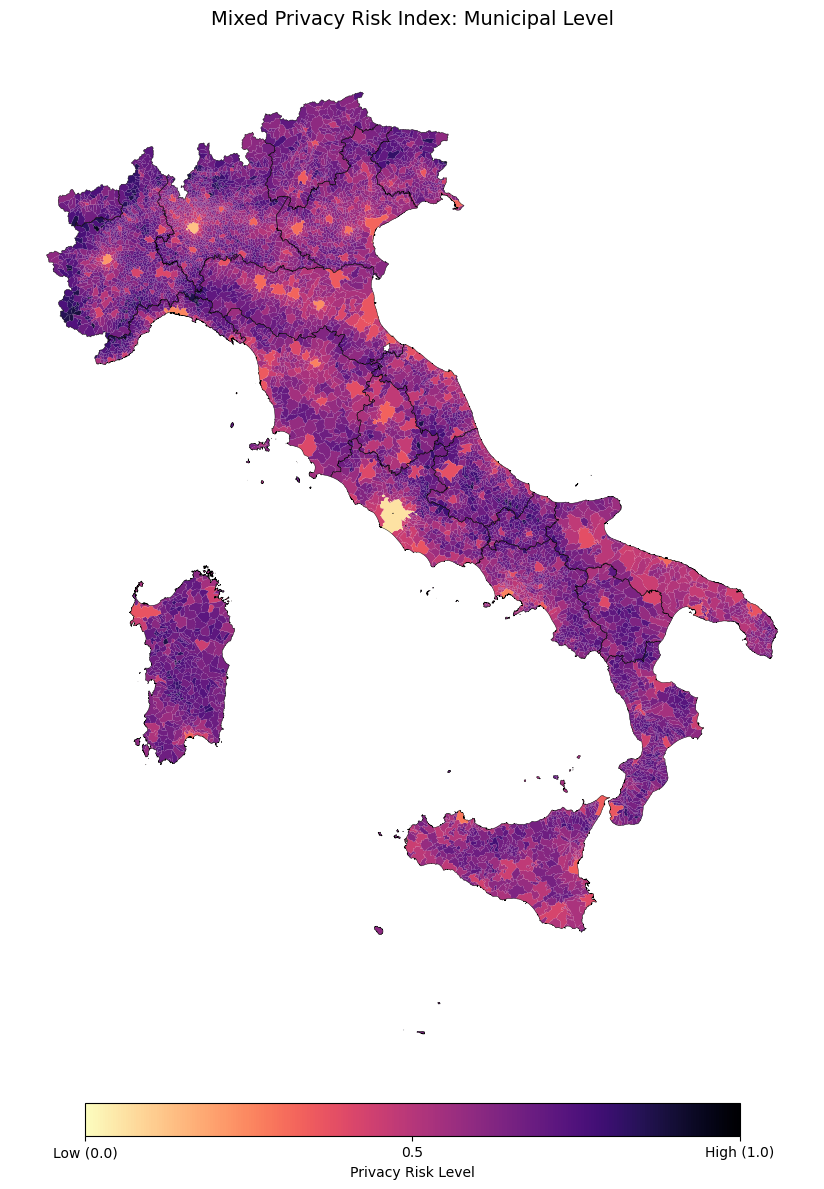

In [46]:
# ============================================================
# Sezione 6 — Mappe finali: caricamento shapefile e join
# ============================================================

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


# ------------------------------------------------------------
# Caricamento shapefile
# ------------------------------------------------------------

comuni_sf = gpd.read_file(
    "./Limiti01012022/Com01012022/Com01012022_WGS84.shp"
)

province_sf = gpd.read_file(
    "./Limiti01012022/ProvCM01012022/ProvCM01012022_WGS84.shp"
)

regioni_sf = gpd.read_file(
    "./Limiti01012022/Reg01012022/Reg01012022_WGS84.shp"
)


# Controlli equivalenti agli output di st_read()

print("Comuni:", comuni_sf.shape)
print("Province:", province_sf.shape)
print("Regioni:", regioni_sf.shape)


# ------------------------------------------------------------
# Uniformazione codici
# ------------------------------------------------------------

comuni_sf["PRO_COM"] = (
    comuni_sf["PRO_COM"]
    .astype(int)
    .astype(str)
    .str.zfill(6)
)

comparison_df["Codice.comune"] = (
    comparison_df["Codice.comune"]
    .astype(int)
    .astype(str)
    .str.zfill(6)
)

regioni_sf["COD_REG"] = regioni_sf["COD_REG"].astype(str)
province_sf["SIGLA"] = province_sf["SIGLA"].astype(str)


# ------------------------------------------------------------
# Join comuni + indice composito
# ------------------------------------------------------------

comuni_map_misto = (
    comuni_sf
    .merge(
        comparison_df[
            ["Codice.comune", "Comune", "Indice_composito_misto"]
        ],
        how="left",
        left_on="PRO_COM",
        right_on="Codice.comune"
    )
    .dropna(subset=["Indice_composito_misto"])
)


# Top 20 comuni sulla mappa comunale

top20_misto = (
    comuni_map_misto
    .sort_values(
        "Indice_composito_misto",
        ascending=False
    )
    ["Comune"]
    .head(20)
    .tolist()
)

print("Top 20 sulla mappa comunale:")
print(top20_misto)


# ------------------------------------------------------------
# Aggregazione provinciale
# ------------------------------------------------------------

df_prov = (
    comuni_sf
    .drop(columns="geometry")
    .merge(
        comparison_df[
            ["Codice.comune", "Indice_composito_misto"]
        ],
        how="left",
        left_on="PRO_COM",
        right_on="Codice.comune"
    )
    .groupby("COD_PROV", as_index=False)
    ["Indice_composito_misto"]
    .mean()
)


# ------------------------------------------------------------
# Aggregazione regionale
# ------------------------------------------------------------

df_reg = (
    comuni_sf
    .drop(columns="geometry")
    .merge(
        comparison_df[
            ["Codice.comune", "Indice_composito_misto"]
        ],
        how="left",
        left_on="PRO_COM",
        right_on="Codice.comune"
    )
    .groupby("COD_REG", as_index=False)
    ["Indice_composito_misto"]
    .mean()
)

df_reg["COD_REG"] = df_reg["COD_REG"].astype(str)


# ------------------------------------------------------------
# Join con shapefile provinciali e regionali
# ------------------------------------------------------------

province_map_misto = province_sf.merge(
    df_prov,
    on="COD_PROV",
    how="left"
)

regioni_map_misto = regioni_sf.merge(
    df_reg,
    on="COD_REG",
    how="left"
)


# ============================================================
# Mappa A — Comunale
# ============================================================

fig, ax = plt.subplots(figsize=(10, 12))


# Comuni colorati per indice

comuni_map_misto.plot(
    column="Indice_composito_misto",
    cmap="magma_r",       # equivalente a direction = -1 in ggplot
    linewidth=0,
    ax=ax,
    vmin=0,
    vmax=1
)


# Confini regionali

regioni_sf.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.3
)


# Barra legenda orizzontale

norm = mpl.colors.Normalize(
    vmin=0,
    vmax=1
)

sm = mpl.cm.ScalarMappable(
    cmap="magma_r",
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.03,
    pad=0.02
)

cbar.set_label(
    "Privacy Risk Level",
    fontsize=10
)

cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(
    [
        "Low (0.0)",
        "0.5",
        "High (1.0)"
    ]
)


# Titolo

ax.set_title(
    "Mixed Privacy Risk Index: Municipal Level",
    fontsize=14,
    pad=15
)


# Equivalente a theme_void()

ax.axis("off")

plt.tight_layout()
plt.show()

In [49]:
#Ci_finale_tutti_comuni 
comparison_df.to_csv('./Materiale/Ci_finale_tutti_comuni_BIS.csv',index=False)